In [ ]:
%tensorflow_version 1.x

TensorFlow 1.x selected.


In [ ]:
pip install keras_layer_normalization

  Created wheel for keras-layer-normalization: filename=keras_layer_normalization-0.14.0-cp36-none-any.whl size=5268 sha256=751ce7ee193e577d93f355107b095789b3549d737ba40e3654fce8fc8d809f4f
  Stored in directory: /root/.cache/pip/wheels/54/80/22/a638a7d406fd155e507aa33d703e3fa2612b9eb7bb4f4fe667
Successfully built keras-layer-normalization


In [ ]:
import os
import random
import scipy.io
import keras
import tensorflow as tf
from google.colab.patches import cv2_imshow
import numpy as np
from glob import glob
from google.colab import drive
import matplotlib.pyplot as plt

from keras.layers import Input, Conv2DTranspose, LSTM, ConvLSTM2D, BatchNormalization, TimeDistributed, Conv2D, Flatten, Dense, MaxPooling2D
from keras.models import Sequential, load_model
from keras_layer_normalization import LayerNormalization

drive.mount('/content/gdrive',force_remount=True)   

Using TensorFlow backend.


Mounted at /content/gdrive


In [ ]:
#FUSION2020_FOLDER_PATH = "/content/gdrive/My Drive/FUSION2020"
FUSION2020_FOLDER_PATH = "/content/gdrive/My Drive/FUSION2020"
#FUSION2020_FOLDER_PATH = "/content/gdrive/My Drive/escritorio/Doctorado/2019-2020/Congresos/FUSION2020"
NUMBER_OF_EXAMPLES_FOR_EACH_CLASS = 60
NUMBER_OF_EXAMPLES_FOR_TRAINING_AND_VALIDATION = 3
EXPERIMENTS= 20

In [ ]:

def get_training_and_validation_example_list(path, number_of_examples):
  training_matrix_paths = []
  for i in range(1, number_of_examples+1):
    training_matrix_paths = training_matrix_paths + glob(os.path.join(path, "*_{}.mat".format(i)))
  return training_matrix_paths

def get_all_matrix_paths(path):
  number_of_matrix_paths = len(glob(os.path.join(path, "*.mat")))
  all_matrix_paths = []
  for i in range(1, number_of_matrix_paths+1):
    all_matrix_paths = all_matrix_paths + glob(os.path.join(path, "*_{}.mat".format(i)))
  return all_matrix_paths

def read_all_matrix_from_object_folder_obtaining_training_and_evaluation(path, number_of_training_examples):
  all_matrix_paths = get_all_matrix_paths(path)
  training_matrix_paths = get_training_and_validation_example_list(path,number_of_training_examples)
  print(training_matrix_paths)
  training_object_data = None
  evaluation_object_data = None
  training_matrix_index = 0
  evaluation_matrix_index = 0

  for matrix_path in all_matrix_paths:
    matrix = scipy.io.loadmat(matrix_path)
    matrix = matrix["datos2"]
    matrix = matrix[10:,2:6].transpose()
    print("Matrix {} shape".format(matrix_path))
    print(matrix.shape)
    if matrix_path in training_matrix_paths:
      if training_object_data is None:
        training_object_data = -1 * np.ones((len(training_matrix_paths), matrix.shape[0], matrix.shape[1]))
      training_object_data[training_matrix_index] = matrix
      training_matrix_index += 1   

    else:
      if evaluation_object_data is None:
        evaluation_object_data = -1 * np.ones((NUMBER_OF_EXAMPLES_FOR_EACH_CLASS-len(training_matrix_paths), matrix.shape[0], matrix.shape[1]))
      evaluation_object_data[evaluation_matrix_index] = matrix
      evaluation_matrix_index += 1

  print(training_object_data.shape)
  print(evaluation_object_data.shape)
  return training_object_data, evaluation_object_data

def read_training_and_evaluation_objects_data(path,number_of_training_examples):
  nom_labels = ["ball_l_", "basket_ball_", "coke_bottle_", "energy_drink_can_", "gears_box_", "grey_mouse_", "mixed_nut_", "mixed_washer_", "mouse_", "nestea_bottle_",
                "nut_m6_", "nut_m8_", "nut_m10_", "rivets_box_", "roll_wheel_", "rubber_pipe_", "soda_can_", "sponge_rough_", "sponge_rough_inclusions_", "sponge_scrunchy_",
                "sponge_smooth_", "sponge_smooth_inclusions_", "sponge_tube_", "water_bottle_"]
  all_objects_folders_path = []
  for nom_label in nom_labels:
    all_objects_folders_path = all_objects_folders_path + glob(os.path.join(path,nom_label))
  all_objects_training_data = None
  all_objects_evaluation_data = None
  all_objects_training_labels = []
  all_objects_evaluation_labels = []

  for object_index, object_folder_path in enumerate(all_objects_folders_path):
    #print(object_folder_path)
    training_object_data, evaluation_object_data = read_all_matrix_from_object_folder_obtaining_training_and_evaluation(object_folder_path,number_of_training_examples)

    if all_objects_training_data is None:
      all_objects_training_data = training_object_data
    else:
      all_objects_training_data = np.concatenate((all_objects_training_data, training_object_data), axis = 0)

    if all_objects_evaluation_data is None:
      all_objects_evaluation_data = evaluation_object_data
    else:
      all_objects_evaluation_data = np.concatenate((all_objects_evaluation_data, evaluation_object_data), axis = 0)

    all_objects_training_labels = all_objects_training_labels + number_of_training_examples*[object_index]
    all_objects_evaluation_labels = all_objects_evaluation_labels + (NUMBER_OF_EXAMPLES_FOR_EACH_CLASS-number_of_training_examples)*[object_index]

  return all_objects_training_data, np.array(all_objects_training_labels), all_objects_evaluation_data, np.array(all_objects_evaluation_labels)

In [ ]:
def train_model(training_data, training_labels):
  seq = Sequential()
  # # # # #
  seq.add(LSTM(1000, input_shape=(4,41), return_sequences=True, activation = "tanh"))
  seq.add(LSTM(100, return_sequences=False, activation = "tanh"))
  # # # # #
  #seq.add(Flatten())
  seq.add(Dense(24, activation = "softmax"))
  print(seq.summary())

  seq.compile(optimizer=keras.optimizers.Adam(lr=0.00001),
              loss="categorical_crossentropy",
              metrics=['accuracy'])
  history = seq.fit(training_data, training_labels, batch_size = 16, epochs=700, validation_split = 0.2, shuffle = True)
  return seq, history

In [ ]:
print("Loading data.")
for ite in range (1, EXPERIMENTS+1):
    print("Experiment {}".format(ite))
    #examples, labels = read_objects_data(os.path.join(FUSION2020_FOLDER_PATH, "Datos-arduino"))
    all_objects_training_data, all_objects_training_labels, all_objects_evaluation_data, all_objects_evaluation_labels = read_training_and_evaluation_objects_data(os.path.join(FUSION2020_FOLDER_PATH, "experiments/21noNorm_tactile_images/propioceptive_data/Kinesthetic-Data_Norm_{}".format(ite)), NUMBER_OF_EXAMPLES_FOR_TRAINING_AND_VALIDATION)
    all_objects_training_labels = keras.utils.to_categorical(all_objects_training_labels)
    all_objects_evaluation_labels = keras.utils.to_categorical(all_objects_evaluation_labels)
    print(all_objects_training_data.shape)
    print(all_objects_training_labels.shape)
    print(all_objects_evaluation_data.shape)
    print(all_objects_evaluation_labels.shape)
    #read_objects_data(os.path.join(FUSION2020_FOLDER_PATH, "DatasetIEEESensors3DCNN"))
    reshaped_all_objects_training_data = all_objects_training_data
    reshaped_all_objects_training_data = list(reshaped_all_objects_training_data)
    all_objects_training_labels = list(all_objects_training_labels)
    zip_list = list(zip(reshaped_all_objects_training_data, all_objects_training_labels))
    random.shuffle(zip_list)
    reshaped_all_objects_training_data, all_objects_training_labels = zip(*zip_list)
    reshaped_all_objects_training_data = np.array(reshaped_all_objects_training_data)
    all_objects_training_labels = np.array(all_objects_training_labels)
    print(reshaped_all_objects_training_data.shape)

    print(np.min(reshaped_all_objects_training_data))
    print(np.max(reshaped_all_objects_training_data))
    model, history = train_model(reshaped_all_objects_training_data, all_objects_training_labels)
    print(all_objects_training_labels[9])
    reshaped_all_objects_evaluation_data = all_objects_evaluation_data

    score = model.evaluate(reshaped_all_objects_evaluation_data, all_objects_evaluation_labels)
    print('Test loss: {} / Test accuracy: {}'.format(score[0], score[1]))

    output_file = os.path.join(FUSION2020_FOLDER_PATH,'experiments/results/{}TnoNorm/21/{}/Kin_evaluation_without_norm.txt'.format(NUMBER_OF_EXAMPLES_FOR_TRAINING_AND_VALIDATION, ite))

    with open(output_file, 'w') as f:
      print('Test loss: {} / Test accuracy: {}'.format(score[0], score[1]), file=f)  

    evaluation_predictions = model.predict(reshaped_all_objects_evaluation_data)
    print(evaluation_predictions.shape)

    output_matrix = -1 * np.ones((evaluation_predictions.shape[1],evaluation_predictions.shape[0]))

    for i in range(reshaped_all_objects_evaluation_data.shape[0]):
      output_matrix[:,i] = evaluation_predictions[i]

    scipy.io.savemat(os.path.join(FUSION2020_FOLDER_PATH,'experiments/results/{}TnoNorm/21/{}/LSTMpythonArduino_without_norm.mat'.format(NUMBER_OF_EXAMPLES_FOR_TRAINING_AND_VALIDATION,ite)), {'output':output_matrix})



Se han truncado las últimas 5000 líneas del flujo de salida.
57/57 [==============================] - 1s 12ms/step - loss: 0.2879 - accuracy: 0.9825 - val_loss: 1.3042 - val_accuracy: 0.7333
Epoch 394/700
57/57 [==============================] - 1s 12ms/step - loss: 0.2868 - accuracy: 0.9825 - val_loss: 1.3060 - val_accuracy: 0.6667
Epoch 395/700
57/57 [==============================] - 1s 12ms/step - loss: 0.2847 - accuracy: 0.9825 - val_loss: 1.3085 - val_accuracy: 0.7333
Epoch 396/700
57/57 [==============================] - 1s 12ms/step - loss: 0.2835 - accuracy: 0.9825 - val_loss: 1.3123 - val_accuracy: 0.7333
Epoch 397/700
57/57 [==============================] - 1s 12ms/step - loss: 0.2828 - accuracy: 1.0000 - val_loss: 1.3160 - val_accuracy: 0.7333
Epoch 398/700
57/57 [==============================] - 1s 12ms/step - loss: 0.2818 - accuracy: 1.0000 - val_loss: 1.3155 - val_accuracy: 0.7333
Epoch 399/700
57/57 [==============================] - 1s 12ms/step - loss: 0.2798 - accu

In [ ]:
example_to_print = 10
print(all_objects_training_data)
print(np.max(all_objects_training_data))
print(np.min(all_objects_training_data))

[[[0.53681633 0.53681633 0.53681633 ... 0.62302041 0.62302041 0.62302041]
  [0.54187755 0.54187755 0.54187755 ... 0.67861224 0.67861224 0.67861224]
  [0.16595918 0.16595918 0.16595918 ... 0.44538776 0.44538776 0.44538776]
  [0.1924898  0.1924898  0.1924898  ... 0.43534694 0.43534694 0.43534694]]

 [[0.59510204 0.59510204 0.59510204 ... 0.69142857 0.69142857 0.69142857]
  [0.56865306 0.56865306 0.56865306 ... 0.70538776 0.70538776 0.70538776]
  [0.15012245 0.15012245 0.15012245 ... 0.48342857 0.48342857 0.48342857]
  [0.23134694 0.23134694 0.23134694 ... 0.54163265 0.54163265 0.54163265]]

 [[0.59257143 0.59257143 0.59510204 ... 0.66604082 0.66604082 0.67363265]
  [0.60620408 0.6035102  0.60081633 ... 0.73493878 0.74293878 0.7402449 ]
  [0.20187755 0.19967347 0.19967347 ... 0.50791837 0.52008163 0.52293878]
  [0.19183673 0.19183673 0.19183673 ... 0.43820408 0.43893878 0.47918367]]

 ...

 [[0.74457143 0.74457143 0.74457143 ... 0.76228571 0.76489796 0.76228571]
  [0.73755102 0.7402449  0

In [ ]:
reshaped_all_objects_training_data = all_objects_training_data
reshaped_all_objects_training_data = list(reshaped_all_objects_training_data)
all_objects_training_labels = list(all_objects_training_labels)
zip_list = list(zip(reshaped_all_objects_training_data, all_objects_training_labels))
random.shuffle(zip_list)
reshaped_all_objects_training_data, all_objects_training_labels = zip(*zip_list)
reshaped_all_objects_training_data = np.array(reshaped_all_objects_training_data)
all_objects_training_labels = np.array(all_objects_training_labels)
print(reshaped_all_objects_training_data.shape)

(360, 4, 41)


In [ ]:
print(np.min(reshaped_all_objects_training_data))
print(np.max(reshaped_all_objects_training_data))
model, history = train_model(reshaped_all_objects_training_data, all_objects_training_labels)
print(all_objects_training_labels[9])
reshaped_all_objects_evaluation_data = all_objects_evaluation_data

score = model.evaluate(reshaped_all_objects_evaluation_data, all_objects_evaluation_labels)
print('Test loss: {} / Test accuracy: {}'.format(score[0], score[1]))
evaluation_predictions = model.predict(reshaped_all_objects_evaluation_data)
print(evaluation_predictions.shape)

output_matrix = -1 * np.ones((evaluation_predictions.shape[1],evaluation_predictions.shape[0]))

for i in range(reshaped_all_objects_evaluation_data.shape[0]):
  output_matrix[:,i] = evaluation_predictions[i]

scipy.io.savemat(os.path.join(FUSION2020_FOLDER_PATH,'experiments/results/21/1/LSTMpythonArduino.mat'), {'output':output_matrix})

0.05746938775510203
0.9956734693877551
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_1 (LSTM)                (None, 4, 1000)           4168000   
_________________________________________________________________
lstm_2 (LSTM)                (None, 100)               440400    
_________________________________________________________________
dense_1 (Dense)              (None, 24)                2424      
Total params: 4,610,824
Trainable params: 4,610,824
Non-trainable params: 0
_________________________________________________________________
None

Train on 288 samples, validate on 72 samples
Epoch 1/1000
272/288 [===========================>..] - ETA: 0s - loss: 3.1801 - accuracy: 0.0404

KeyboardInterrupt: ignored

In [ ]:
print(all_objects_training_labels[9])



/content/gdrive/My Drive/escritorio/Doctorado/2019-2020/Congresos/FUSION2020/experiments/results/21/1/LSTMpythonArduino.mat


In [ ]:
reshaped_all_objects_evaluation_data = all_objects_evaluation_data

score = model.evaluate(reshaped_all_objects_evaluation_data, all_objects_evaluation_labels)
print('Test loss: {} / Test accuracy: {}'.format(score[0], score[1]))

1080/1080 [==============================] - 1s 1ms/step
Test loss: 1.3856155532377739 / Test accuracy: 0.5657407641410828


In [ ]:
evaluation_predictions = model.predict(reshaped_all_objects_evaluation_data)
print(evaluation_predictions.shape)

output_matrix = -1 * np.ones((evaluation_predictions.shape[1],evaluation_predictions.shape[0]))

for i in range(reshaped_all_objects_evaluation_data.shape[0]):
  output_matrix[:,i] = evaluation_predictions[i]

scipy.io.savemat(os.path.join(FUSION2020_FOLDER_PATH,'LSTMpythonArduino.mat'), {'output':output_matrix})

(1080, 24)


dict_keys(['val_loss', 'val_accuracy', 'loss', 'accuracy'])


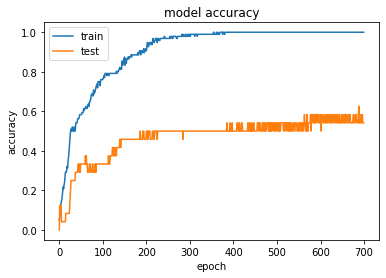

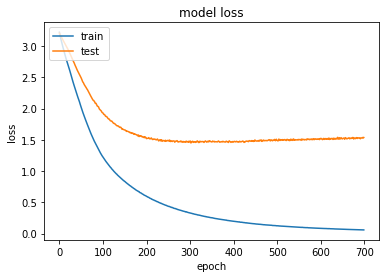

In [ ]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()